In [1]:
!python --version


Python 3.10.12


In [2]:
import os
import numpy as np
import shutil
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

# Paths
input_dataset = "/kaggle/input/datasets/maheshrathodg12/vehicles"
output_dataset = "/kaggle/working/dataset2"

# Reset output directory
if os.path.exists(output_dataset):
    shutil.rmtree(output_dataset)
os.makedirs(output_dataset)

# Image augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

# List class folders
classes = os.listdir(input_dataset)

for class_name in tqdm(classes, desc="Processing Classes"):
    class_path = os.path.join(input_dataset, class_name)

    if not os.path.isdir(class_path):
        continue

    # Collect images (including subfolders)
    images = []
    for root, _, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith(("jpg", "jpeg", "png")):
                images.append(os.path.join(root, file))

    # 🔴 Skip empty classes
    if len(images) == 0:
        print(f"⚠️ Skipping '{class_name}' — No images found.")
        continue

    # Create output class folder
    output_class_path = os.path.join(output_dataset, class_name)
    os.makedirs(output_class_path, exist_ok=True)

    num_images_generated = 0
    image_index = 0
    target_images = 2000

    with tqdm(total=target_images, desc=f"Augmenting {class_name}", leave=False) as pbar:
        while num_images_generated < target_images:
            img_path = images[image_index % len(images)]
            image_index += 1

            img = load_img(img_path, target_size=(100,100))
            img_array = img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)

            aug_iter = datagen.flow(img_array, batch_size=1)

            for _ in range(min(5, target_images - num_images_generated)):
                aug_img = array_to_img(next(aug_iter)[0])
                save_path = os.path.join(
                    output_class_path,
                    f"aug_{num_images_generated}.png"
                )
                aug_img.save(save_path)

                num_images_generated += 1
                pbar.update(1)

print("✅ Data augmentation complete. Augmented dataset saved in '/kaggle/working/dataset2'")


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Processing Classes: 100%|██████████| 3/3 [00:37<00:00, 12.38s/it]        

✅ Data augmentation complete. Augmented dataset saved in '/kaggle/working/dataset2'


In [3]:
import cv2
import os
import numpy as np
from tqdm import tqdm

def preprocess_and_save_with_subclasses2(input_dir, output_dir, target_size=(100,100)):
    """
    Preprocess images from input directory (with subclasses) and save to output directory.
    - Maintains the original folder structure (subclasses).
    - Applies image preprocessing: grayscale, CLAHE, Gaussian blur, Canny edge detection, and overlays edges in red.
    """
    # Initialize CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    list1=os.listdir(input_dir)

    for subclass in list1:
        subclass_path = os.path.join(input_dir, subclass)
        if not os.path.isdir(subclass_path):
            continue  # Skip files, only process folders
        
        # Create corresponding subclass folder in the output directory
        output_subclass_path = os.path.join(output_dir, subclass)
        if not os.path.exists(output_subclass_path):
            os.makedirs(output_subclass_path)
        
        # Process each image in the subclass folder
        for image_name in tqdm(os.listdir(subclass_path), desc=f"Processing {subclass}"):
            image_path = os.path.join(subclass_path, image_name)
            image = cv2.imread(image_path)
            
            if image is None:
                continue  # Skip invalid files
            
            # Resize image
            image = cv2.resize(image, target_size)
            
            # Convert to grayscale
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            
            # Apply CLAHE for contrast enhancement
            clahe_enhanced = clahe.apply(gray)
            
            # Apply Gaussian blur to reduce noise
            blurred = cv2.GaussianBlur(clahe_enhanced, (5, 5), 0)
            
            # Apply Canny edge detection
            edges = cv2.Canny(blurred, threshold1=50, threshold2=150)
            
            # Create an RGB edge map (edges in red)
            edges_colored = np.zeros_like(image)  # Create a black RGB image
            edges_colored[:, :, 2] = edges  # Set red channel to edges
            
            # Overlay the edges onto the original image
            combined = cv2.addWeighted(image, 0.8, edges_colored, 0.5, 0)
            
            # Save the processed image to the corresponding output folder
            output_path = os.path.join(output_subclass_path, image_name)
            cv2.imwrite(output_path, combined)


In [4]:
# Define input and output directories
input_directory = '/kaggle/working/dataset2'  # Contains subclass folders
output_directory = '/kaggle/working/dataset_preprocessed'  # Preprocessed images will be saved here

# Run preprocessing
preprocess_and_save_with_subclasses2(input_directory, output_directory)


Processing fire trucks: 100%|██████████| 2000/2000 [00:04<00:00, 452.89it/s]


In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
import cv2 
import os
import random

In [6]:
import os
import cv2
import numpy as np

def load_dataset(path_dataset, target_size=(100,100)): 
    dataset = []
    labels = []

    # Iterate over all folders in dataset_path
    for label in os.listdir(path_dataset):
        class_path = os.path.join(path_dataset, label)

        # check if the directory exists
        if os.path.isdir(class_path):
            # Initialize a counter for images in each class
            images_counter = 0
            
            # Iterate over all images in folder/class
            for image_name in os.listdir(class_path):
                image_path = os.path.join(class_path, image_name)

                # Load image with OpenCV
                image = cv2.imread(image_path)

                # Check if the image was loaded successfully
                if image is not None:
                    # Resize the image
                    image = cv2.resize(image, target_size)
                    # Get image dimensions
                    (h, w) = image.shape[:2]
                    
                    # Step 1: Apply random rotation between 0 to 5 degrees
                    angle = random.uniform(0, 5)  # Random angle between 0 and 5 degrees
                    center = (w // 2, h // 2)  # Center of the image
                    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)  # Rotation matrix
                    rotated_image = cv2.warpAffine(image, rotation_matrix, (w, h))
                    
                    # Step 2: Apply right-to-left flip
                    image = cv2.flip(rotated_image, 1)  # Flip horizontally
                    # Add image and label to dataset
                    dataset.append(image)
                    labels.append(label)


                else:
                    print(f"Error loading image: {image_path}")

    return np.array(dataset), np.array(labels)

dataset_path = "/kaggle/working/dataset_preprocessed"
dataset, labels = load_dataset(dataset_path) 

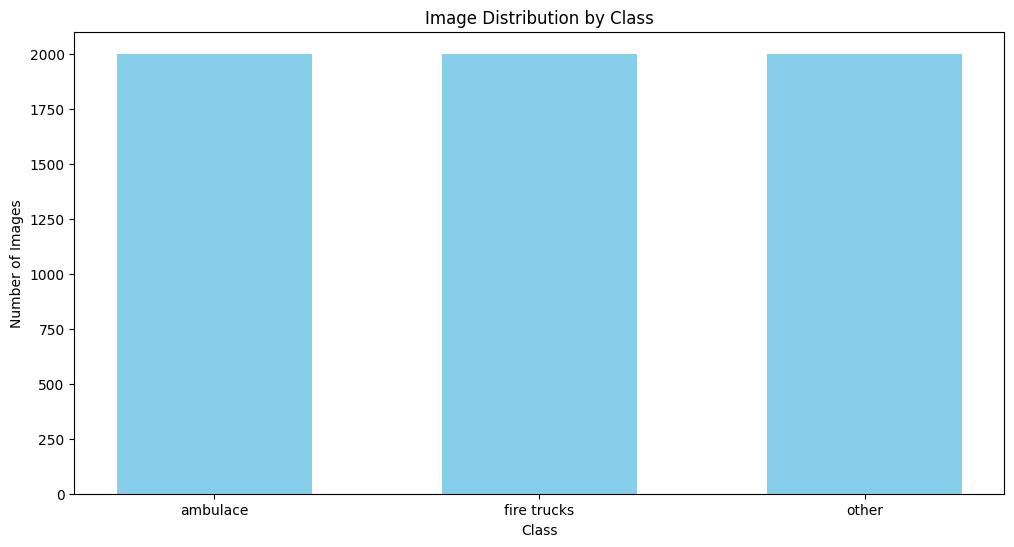

In [7]:
unique_labels, counts = np.unique(labels, return_counts=True)
class_counts = dict(zip(unique_labels, counts))

fig, ax = plt.subplots(figsize=(12, 6)) 
bars = ax.bar(class_counts.keys(), class_counts.values(), color='skyblue', width=0.6)  

ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.set_title('Image Distribution by Class')

plt.show()

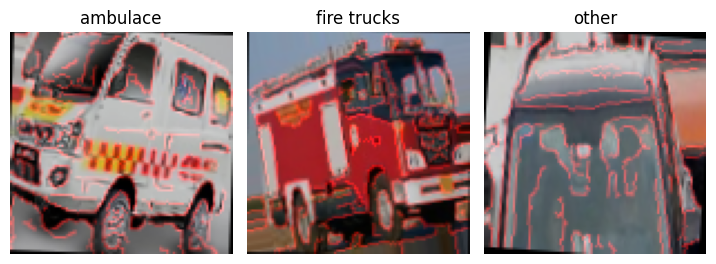

In [8]:
import random
import matplotlib.pyplot as plt

def show_samples(dataset, labels, classes, num_samples):
    plt.figure(figsize=(12, 6))
    
    for i, class_name in enumerate(classes[:num_samples]):  # Show only the first num_samples classes
        indices_class = np.where(labels == class_name)[0]
        sample_index = random.choice(indices_class)
        
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(cv2.cvtColor(dataset[sample_index], cv2.COLOR_BGR2RGB))
        plt.title(f'{class_name}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()


unique_classes = np.unique(labels)
show_samples(dataset, labels, unique_classes, num_samples=5)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels into numbers
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)



X_train, X_temp, y_train, y_temp = train_test_split(dataset, encoded_labels, test_size=0.2, random_state=42)


X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


def preprocess_image(image):
    resized_image = cv2.resize(image, (100,100))
    
    normalized_image = resized_image / 255.0
    return normalized_image


X_train = np.array([preprocess_image(image) for image in X_train])
X_test = np.array([preprocess_image(image) for image in X_test])
X_val = np.array([preprocess_image(image) for image in X_val])


print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (4800, 100, 100, 3)
Shape of X_val: (600, 100, 100, 3)
Shape of X_test: (600, 100, 100, 3)
Shape of y_train: (4800,)
Shape of y_val: (600,)
Shape of y_test: (600,)


In [10]:
!pip install efficientnet

  Obtaining dependency information for efficientnet from https://files.pythonhosted.org/packages/53/97/84f88e581d6ac86dcf1ab347c497c4c568c38784e3a2bd659b96912ab793/efficientnet-1.1.1-py3-none-any.whl.metadata
  Obtaining dependency information for keras-applications<=1.0.8,>=1.0.7 from https://files.pythonhosted.org/packages/71/e3/19762fdfc62877ae9102edf6342d71b28fbfd9dea3d2f96a882ce099b03f/Keras_Applications-1.0.8-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.7 MB/s eta 0:00:00


In [11]:
from efficientnet.tfkeras import EfficientNetB0
from tensorflow.keras import models
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1
from tensorflow.keras.optimizers import RMSprop
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
# Define the number of classes
num_classes = len(np.unique(labels))
# Load EfficientNetB0 without the top classification layers
efficientnet_model = EfficientNetB0(input_shape=(100,100, 3), include_top=False, weights='/kaggle/input/image-net/keras/default/1/efficientnet-b0_weights_tf_dim_ordering_tf_kernels_autoaugment_notop.h5')
# Create a new model
inputs = efficientnet_model.input
# Get the output of the last convolutional layer for Grad-CAM
conv_output = efficientnet_model.layers[-1].output
# Add a Global Average Pooling layer
x = GlobalAveragePooling2D()(conv_output)
# Add dense layers on top
x = Dense(128, kernel_regularizer=l1(0.0001), activation='relu')(x)
x = BatchNormalization(renorm=True)(x)
x = Dropout(0.3)(x)
x = Dense(64, kernel_regularizer=l1(0.0001), activation='relu')(x)
x = BatchNormalization(renorm=True)(x)
x = Dropout(0.3)(x)
x = Dense(32, kernel_regularizer=l1(0.0001), activation='relu')(x)
x = BatchNormalization(renorm=True)(x)
x = Dropout(0.3)(x)
# Final classification layer
outputs = Dense(units=num_classes, activation='softmax')(x)
# Combine into the model
model = models.Model(inputs=inputs, outputs=outputs)
# Define Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
# Compile the model
custom_optimizer = RMSprop(learning_rate=0.0001)
model.compile(optimizer=custom_optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

Epoch 1/10


2026-02-26 07:24:31.996418: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


150/150 [==============================] - 42s 71ms/step - loss: 1.5716 - accuracy: 0.5698 - val_loss: 1.3825 - val_accuracy: 0.6767
Epoch 2/10
150/150 [==============================] - 8s 55ms/step - loss: 1.1655 - accuracy: 0.7875 - val_loss: 0.9674 - val_accuracy: 0.8800
Epoch 3/10
150/150 [==============================] - 8s 55ms/step - loss: 0.9449 - accuracy: 0.8790 - val_loss: 0.7768 - val_accuracy: 0.9600
Epoch 4/10
150/150 [==============================] - 8s 54ms/step - loss: 0.7924 - accuracy: 0.9452 - val_loss: 0.6794 - val_accuracy: 0.9917
Epoch 5/10
150/150 [==============================] - 8s 55ms/step - loss: 0.7082 - accuracy: 0.9767 - val_loss: 0.6351 - val_accuracy: 0.9967
Epoch 6/10
150/150 [==============================] - 8s 54ms/step - loss: 0.6595 - accuracy: 0.9894 - val_loss: 0.6103 - val_accuracy: 0.9950
Epoch 7/10
150/150 [==============================] - 8s 54ms/step - loss: 0.6277 - accuracy: 0.9908 - val_loss: 0.5863 - val_accuracy: 0.9983
Epoch 8/1

In [12]:
model.save("efficientnet.h5")


/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


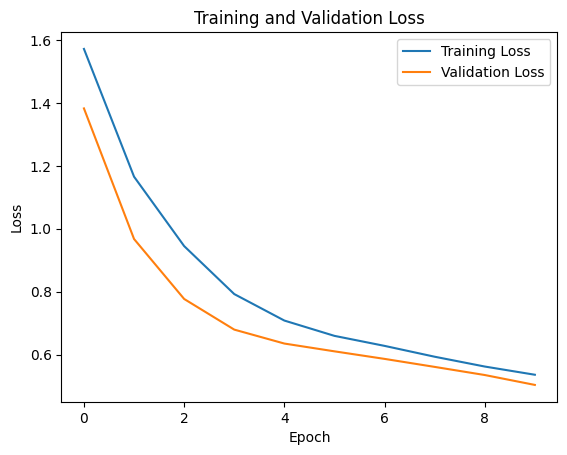

In [13]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

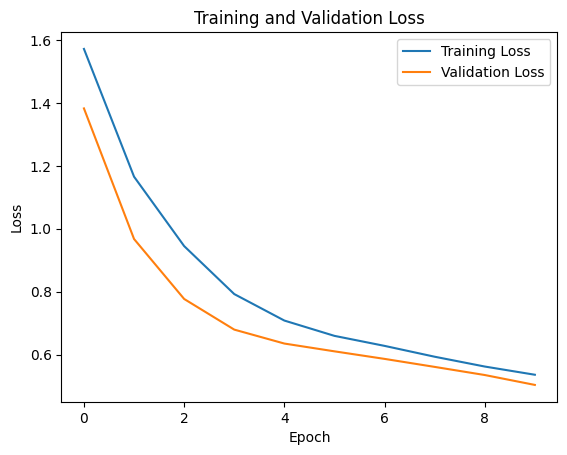

In [14]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

19/19 [==============================] - 1s 13ms/step
Test Accuracy: 1.0000


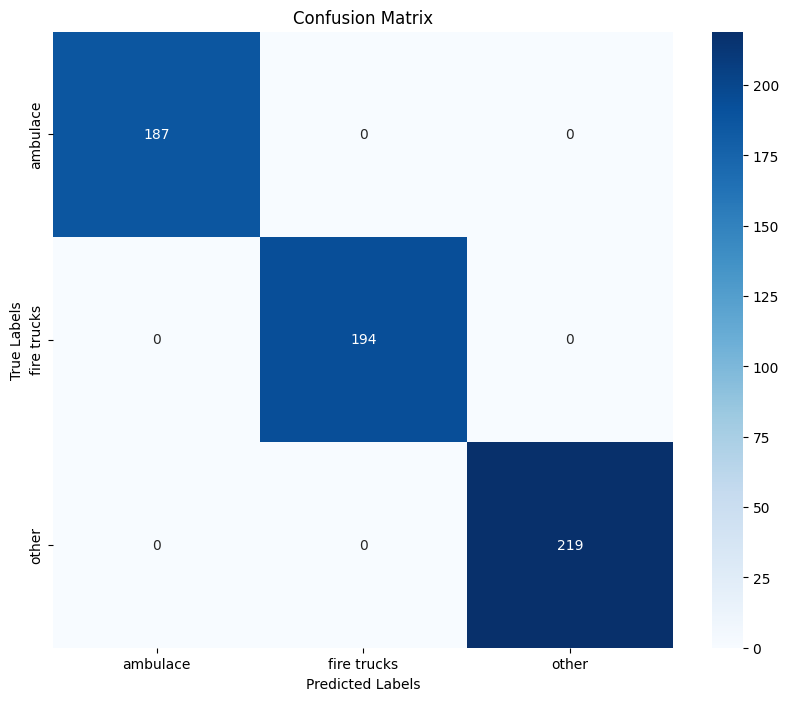

Classification Report:
              precision    recall  f1-score   support

    ambulace     1.0000    1.0000    1.0000       187
 fire trucks     1.0000    1.0000    1.0000       194
       other     1.0000    1.0000    1.0000       219

    accuracy                         1.0000       600
   macro avg     1.0000    1.0000    1.0000       600
weighted avg     1.0000    1.0000    1.0000       600



In [15]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions and predicted classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = y_test

# Calculate test accuracy
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_encoder.classes_, digits=4))


Last Conv Layer: top_conv


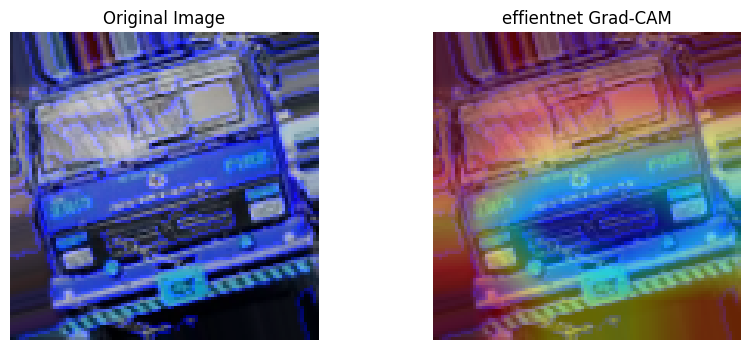

In [16]:
# =========================
# GRAD-CAM (CELL 2)
# =========================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# -------------------------
# Grad-CAM Function
# -------------------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_output = predictions[:, pred_index]

    grads = tape.gradient(class_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

# -------------------------
# Overlay Function
# -------------------------
def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    return cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)

# -------------------------
# Select Validation Image
# -------------------------
img = X_val[0]                         # (100,100,3)
img_array = np.expand_dims(img, axis=0)

# -------------------------
# Find Last Conv Layer
# -------------------------
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Last Conv Layer:", last_conv_layer_name)

# -------------------------
# Generate Grad-CAM
# -------------------------
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name
)

# -------------------------
# Display Results
# -------------------------
img_uint8 = np.uint8(255 * img)
gradcam_img = overlay_gradcam(img_uint8, heatmap)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gradcam_img)
plt.title("effientnet Grad-CAM")
plt.axis("off")

plt.show()
